# Laboratorio 5 - Task 1

**Contexto:** control de semáforos en una intersección con flujo variable. Esta entrega es solo de análisis; no se implementa código.

**Supuestos.** Cuatro carriles de entrada, dos fases y dos acciones: mantener o cambiar. Las variables continuas están normalizadas a $[0,1]$.

**Uso responsable de IA.** La IA se usó para ordenar las ideas. Prompt: *"Para un laboratorio de aprendizaje por refuerzo, propone una estructura rigurosa para comparar aproximación lineal y tabular en control de semáforos, sin implementar código."* Funciona porque delimita el dominio y la comparación.

## 1. Vector de características

Para cada carril $j\in\{1,2,3,4\}$: densidad $\rho_j$, velocidad promedio $v_j$ y espera acumulada $\tau_j$. Se agregan la fase actual $p_0,p_1$ y un sesgo.

$$\mathbf{x}(s)=[1,\rho_1,v_1,\tau_1,\ldots,\rho_4,v_4,\tau_4,p_0,p_1]^T\in\mathbb{R}^{15}.$$

| Componente | Rango | Por qué se incluye |
|---|---:|---|
| $1$ (sesgo) | $\{1\}$ | Permite un valor base aun cuando las demás variables sean cero. |
| $\rho_j$, para cada carril | $[0,1]$ | Resume congestión y anticipa la formación de cola. |
| $v_j$, para cada carril | $[0,1]$ | Distingue una vía densa pero móvil de una vía bloqueada. |
| $\tau_j$, para cada carril | $[0,1]$ | Representa el costo de equidad: no dejar un carril esperando demasiado tiempo. |
| $p_0,p_1$ | $\{0,1\}$, con $p_0+p_1=1$ | El mismo tráfico tiene distinto valor según qué movimiento tenga luz verde. |

El vector cubre congestión, flujo, espera y fase. La forma lineal $\hat V(s;\mathbf w)=\mathbf w^T\mathbf x(s)$ no captura interacciones por sí sola. Ejemplos necesarios: $\rho_j(1-v_j)$, $\tau_j(1-p_{\text{verde},j})$ y diferencias de espera entre carriles.

## 2. Cantidad de parámetros y comparación tabular

Para aproximar $V(s)$ con el vector anterior hay **15 parámetros**: uno por característica. Si se requiere aproximar $Q(s,a)$ con dos acciones, la forma lineal usual usa un bloque de pesos por acción; entonces tendría $2\times15=30$ parámetros.

La tabla $Q$ debe distinguir las 12 variables continuas (tres por cada uno de los cuatro carriles), la fase y la acción. Con 10 niveles por variable:

$$|Q|=10^{12}\times2\text{ fases}\times2\text{ acciones}=4\times10^{12}\text{ entradas}. $$

La aproximación lineal usa 30 pesos frente a cuatro billones de entradas. La tabla necesita visitar cada combinación y no comparte aprendizaje entre estados cercanos. La aproximación lineal sí generaliza entre estados similares, pero puede no capturar relaciones no lineales.

La tabla puede ajustar ruido en celdas poco visitadas. El modelo lineal tiene menor riesgo de sobreajuste, pero mayor riesgo de subajuste.

## 3. Por qué TD semi-gradiente llega al punto de TD

Con referencia fija, $J(\mathbf w)=\mathbb E[(V_\pi(S)-\hat V(S;\mathbf w))^2]$. TD usa $R_{t+1}+\gamma\hat V(S_{t+1};\mathbf w)$, que depende de $\mathbf w$.

$$\mathbf w\leftarrow\mathbf w+\alpha\,[R_{t+1}+\gamma\hat V(S_{t+1};\mathbf w)-\hat V(S_t;\mathbf w)]\,\mathbf x(S_t)$$

deriva solo respecto a $\hat V(S_t;\mathbf w)$ e ignora la derivada de la referencia. No minimiza el gradiente completo de $J(\mathbf w)$; converge al punto de TD, que puede diferir del mínimo global.

El error es más grave con $\gamma$ cercano a 1, porque se propaga a más pasos. Para el cruce se recomienda probar $\gamma\in[0.90,0.95]$ y validar espera, equidad y estabilidad.

## 4. Triada mortal y dictamen inicial

La triada mortal combina aproximación de función, *bootstrapping* y aprendizaje fuera de política. El componente más relevante es el **bootstrapping**: una estimación incorrecta de congestión futura entra en la meta TD y afecta decisiones posteriores. El aprendizaje fuera de política importa si se entrena con una política y se evalúa otra.

Deep RL no está justificado automáticamente. Para un cruce aislado, la aproximación lineal con rasgos de interacción puede ser suficiente. Deep RL se justificaría si aparecen relaciones no lineales persistentes, varias intersecciones conectadas o efectos temporales que el vector no captura.

# Laboratorio 5 - Task 2: TD semi-gradiente lineal vs. Q-Learning tabular

Esta entrega implementa un entorno de intersección simplificado compatible con gymnasium.Env, TD semi-gradiente con aproximación lineal y Q-Learning tabular como línea base.

**Convención para conservar el diseño de la Tarea 1.** El entorno expone exactamente tres componentes continuos: densidad, velocidad normalizada y espera normalizada. Para el aproximador lineal, ese estado agregado se replica en los cuatro carriles abstractos del vector de la Tarea 1 y se añaden sesgo y fase one-hot:

$$\mathbf{x}(s)=[1,\rho,v,\tau,\ldots,\rho,v,\tau,p_0,p_1]^T\in\mathbb{R}^{15}.$$

La fase se conserva como variable discreta observable en los rasgos y en la tabla; cada una de las tres componentes continuas sí se discretiza en cinco niveles.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

SEED = 2025
N_EPISODES = 600
MAX_STEPS = 50
GAMMA = 0.95
LINEAR_ALPHA = 0.018
TABULAR_ALPHA = 0.16
EPSILON_START = 0.25
EPSILON_DECAY = 0.992
EPSILON_MIN = 0.02
FLOW_THRESHOLD = 0.15
N_ACTIONS = 2
FEATURE_DIM = 15

np.set_printoptions(precision=4, suppress=True)
print("Configuración:", {
    "episodios": N_EPISODES,
    "pasos_por_episodio": MAX_STEPS,
    "gamma": GAMMA,
    "alpha_lineal": LINEAR_ALPHA,
    "alpha_tabular": TABULAR_ALPHA,
    "semilla": SEED,
})

Configuración: {'episodios': 600, 'pasos_por_episodio': 50, 'gamma': 0.95, 'alpha_lineal': 0.018, 'alpha_tabular': 0.16, 'semilla': 2025}


In [2]:
class SimplifiedIntersectionEnv(gym.Env):
    """Intersección de dos fases con estado continuo agregado de tres componentes."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        max_steps: int = MAX_STEPS,
        flow_threshold: float = FLOW_THRESHOLD,
        render_mode: str | None = None,
    ):
        super().__init__()
        self.max_steps = int(max_steps)
        self.flow_threshold = float(flow_threshold)
        self.render_mode = render_mode
        self.observation_space = spaces.Box(
            low=np.zeros(3, dtype=np.float32),
            high=np.ones(3, dtype=np.float32),
            dtype=np.float32,
        )
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.state = np.zeros(3, dtype=np.float32)
        self.phase = 0
        self.step_count = 0

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)
        self.phase = int(self.np_random.integers(0, 2))
        self.state = self.np_random.uniform(
            low=np.array([0.25, 0.25, 0.00]),
            high=np.array([0.75, 0.85, 0.30]),
        ).astype(np.float32)
        self.step_count = 0
        return self.state.copy(), {"phase": self.phase}

    def step(self, action: int):
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f"Acción inválida: {action}")
        switched = action == 1
        if switched:
            self.phase = 1 - self.phase

        density, speed, waiting = self.state
        arrival = float(np.clip(
            0.08 + 0.025 * density + self.np_random.normal(0.0, 0.008),
            0.0,
            1.0,
        ))
        phase_service = 0.115 if self.phase == 0 else 0.090
        service = float(np.clip(
            phase_service + 0.090 * speed - 0.035 * density
            + self.np_random.normal(0.0, 0.006),
            0.0,
            1.0,
        ))
        switching_cost = 0.025 if switched else 0.0
        next_density = float(np.clip(
            0.78 * density + 0.60 * arrival - 0.95 * service
            + switching_cost + self.np_random.normal(0.0, 0.006),
            0.0,
            1.0,
        ))
        target_speed = float(np.clip(1.0 - next_density - 0.05 * waiting, 0.0, 1.0))
        next_speed = float(np.clip(
            0.70 * speed + 0.30 * target_speed
            - 0.06 * switched + self.np_random.normal(0.0, 0.008),
            0.0,
            1.0,
        ))
        next_waiting = float(np.clip(
            0.80 * waiting + 0.35 * next_density
            + 0.10 * switched - 0.12 * next_speed
            + self.np_random.normal(0.0, 0.008),
            0.0,
            1.0,
        ))

        self.state = np.array(
            [next_density, next_speed, next_waiting],
            dtype=np.float32,
        )
        flow = float(np.clip(service + 0.25 * arrival, 0.0, 1.0))
        reward = float(
            -2.4 * next_waiting
            + (0.65 if flow > self.flow_threshold else 0.0)
            - 0.04 * switched
        )

        self.step_count += 1
        terminated = False
        truncated = self.step_count >= self.max_steps
        info = {
            "phase": self.phase,
            "flow": flow,
            "waiting": next_waiting,
            "switched": switched,
        }
        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        return {
            "step": self.step_count,
            "phase": self.phase,
            "state": self.state.copy(),
        }

    def close(self):
        pass


env_check = SimplifiedIntersectionEnv()
obs, info = env_check.reset(seed=SEED)
print("Observación inicial:", obs, "fase:", info["phase"])
print("Espacios:", env_check.observation_space, env_check.action_space)

Observación inicial: [0.441  0.7463 0.2512] fase: 0
Espacios: Box(0.0, 1.0, (3,), float32) Discrete(2)


In [3]:
def task1_features(state: np.ndarray, phase: int) -> np.ndarray:
    """Vector x(s) de la Tarea 1 adaptado al estado agregado de tres variables."""
    density, speed, waiting = np.asarray(state, dtype=np.float64)
    lane_block = np.tile([density, speed, waiting], 4)
    phase_one_hot = np.array([float(phase == 0), float(phase == 1)])
    return np.concatenate(([1.0], lane_block, phase_one_hot)).astype(np.float64)


def discretize_state(state: np.ndarray, phase: int) -> tuple[int, int, int, int]:
    """Cinco niveles para cada componente continua + fase discreta."""
    bins = np.minimum((np.asarray(state, dtype=np.float64) * 5).astype(int), 4)
    return int(bins[0]), int(bins[1]), int(bins[2]), int(phase)


def epsilon_greedy(values: np.ndarray, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(0, len(values)))
    best = np.flatnonzero(values == np.max(values))
    return int(rng.choice(best))


def linear_q_values(weights: np.ndarray, state: np.ndarray, phase: int) -> np.ndarray:
    return weights @ task1_features(state, phase)


def rolling_mean(values: np.ndarray, window: int = 25) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


def evaluate_fixed_sample(
    weights: np.ndarray,
    q_table: np.ndarray,
    states: np.ndarray,
    phases: np.ndarray,
) -> float:
    linear_values = np.array([
        np.max(linear_q_values(weights, state, int(phase)))
        for state, phase in zip(states, phases)
    ])
    tabular_values = np.array([
        np.max(q_table[discretize_state(state, int(phase))])
        for state, phase in zip(states, phases)
    ])
    return float(np.mean((linear_values - tabular_values) ** 2))


assert task1_features(np.array([0.2, 0.6, 0.4]), 1).shape == (FEATURE_DIM,)
assert discretize_state(np.ones(3), 1) == (4, 4, 4, 1)
print("Dimensión de x(s):", task1_features(np.array([0.2, 0.6, 0.4]), 1).shape)

Dimensión de x(s): (15,)


In [4]:
def train_comparison(
    n_episodes: int = N_EPISODES,
    max_steps: int = MAX_STEPS,
    seed: int = SEED,
):
    linear_env = SimplifiedIntersectionEnv(max_steps=max_steps)
    tabular_env = SimplifiedIntersectionEnv(max_steps=max_steps)
    linear_weights = np.zeros((N_ACTIONS, FEATURE_DIM), dtype=np.float64)
    q_table = np.zeros((5, 5, 5, 2, N_ACTIONS), dtype=np.float64)
    behavior_rng = np.random.default_rng(seed)
    eval_rng = np.random.default_rng(seed + 10_000)
    fixed_states = eval_rng.uniform(0.0, 1.0, size=(100, 3)).astype(np.float32)
    fixed_phases = eval_rng.integers(0, 2, size=100)

    rewards_linear = []
    rewards_tabular = []
    weight_norms = []
    mse_values = []
    epsilons = []

    for episode in range(n_episodes):
        epsilon = max(EPSILON_MIN, EPSILON_START * (EPSILON_DECAY ** episode))
        epsilons.append(epsilon)

        obs, info = linear_env.reset(seed=seed + episode)
        phase = int(info["phase"])
        episode_reward = 0.0
        for _ in range(max_steps):
            features = task1_features(obs, phase)
            action = epsilon_greedy(linear_weights @ features, epsilon, behavior_rng)
            next_obs, reward, terminated, truncated, next_info = linear_env.step(action)
            next_phase = int(next_info["phase"])
            done = terminated or truncated
            next_values = linear_q_values(linear_weights, next_obs, next_phase)
            target = reward if done else reward + GAMMA * np.max(next_values)
            delta = target - linear_weights[action] @ features
            linear_weights[action] += LINEAR_ALPHA * delta * features
            episode_reward += reward
            obs, phase = next_obs, next_phase
            if done:
                break
        rewards_linear.append(episode_reward)
        weight_norms.append(float(np.linalg.norm(linear_weights)))

        obs, info = tabular_env.reset(seed=seed + episode)
        phase = int(info["phase"])
        episode_reward = 0.0
        for _ in range(max_steps):
            state_index = discretize_state(obs, phase)
            action = epsilon_greedy(q_table[state_index], epsilon, behavior_rng)
            next_obs, reward, terminated, truncated, next_info = tabular_env.step(action)
            next_phase = int(next_info["phase"])
            done = terminated or truncated
            next_index = discretize_state(next_obs, next_phase)
            target = reward if done else reward + GAMMA * np.max(q_table[next_index])
            delta = target - q_table[state_index + (action,)]
            q_table[state_index + (action,)] += TABULAR_ALPHA * delta
            episode_reward += reward
            obs, phase = next_obs, next_phase
            if done:
                break
        rewards_tabular.append(episode_reward)

        mse_values.append(evaluate_fixed_sample(
            linear_weights,
            q_table,
            fixed_states,
            fixed_phases,
        ))

    linear_env.close()
    tabular_env.close()
    return {
        "rewards_linear": np.asarray(rewards_linear),
        "rewards_tabular": np.asarray(rewards_tabular),
        "weight_norms": np.asarray(weight_norms),
        "mse_values": np.asarray(mse_values),
        "epsilons": np.asarray(epsilons),
        "linear_weights": linear_weights,
        "q_table": q_table,
        "fixed_states": fixed_states,
        "fixed_phases": fixed_phases,
    }


results = train_comparison()
print("Entrenamiento terminado.")
print("Registros:", {key: value.shape for key, value in results.items() if isinstance(value, np.ndarray)})

Entrenamiento terminado.
Registros: {'rewards_linear': (600,), 'rewards_tabular': (600,), 'weight_norms': (600,), 'mse_values': (600,), 'epsilons': (600,), 'linear_weights': (2, 15), 'q_table': (5, 5, 5, 2, 2), 'fixed_states': (100, 3), 'fixed_phases': (100,)}


In [5]:
linear_returns = results["rewards_linear"]
tabular_returns = results["rewards_tabular"]
linear_curve = rolling_mean(linear_returns)
tabular_curve = rolling_mean(tabular_returns)
curve_diff = linear_curve - tabular_curve
window = 25

sustained_wins = [
    i for i in range(len(curve_diff) - window + 1)
    if np.all(curve_diff[i:i + window] > 0)
]
first_sustained_episode = (sustained_wins[0] + window) if sustained_wins else None
final_linear_mean = float(np.mean(linear_returns[-window:]))
final_tabular_mean = float(np.mean(tabular_returns[-window:]))
final_weight_norm = float(results["weight_norms"][-1])
initial_weight_norm = float(results["weight_norms"][0])
final_mse = float(results["mse_values"][-1])
minimum_mse = float(np.min(results["mse_values"]))

print(f"Recompensa media últimos {window} episodios - lineal: {final_linear_mean:.3f}")
print(f"Recompensa media últimos {window} episodios - tabular: {final_tabular_mean:.3f}")
print("Primer episodio con ventaja lineal sostenida:", first_sustained_episode)
print(f"Norma w inicial/final: {initial_weight_norm:.4f} / {final_weight_norm:.4f}")
print(f"MSE final/mínimo: {final_mse:.6f} / {minimum_mse:.6f}")

Recompensa media últimos 25 episodios - lineal: 30.813
Recompensa media últimos 25 episodios - tabular: 30.214
Primer episodio con ventaja lineal sostenida: 25
Norma w inicial/final: 0.9946 / 7.4642
MSE final/mínimo: 54.921199 / 2.486588


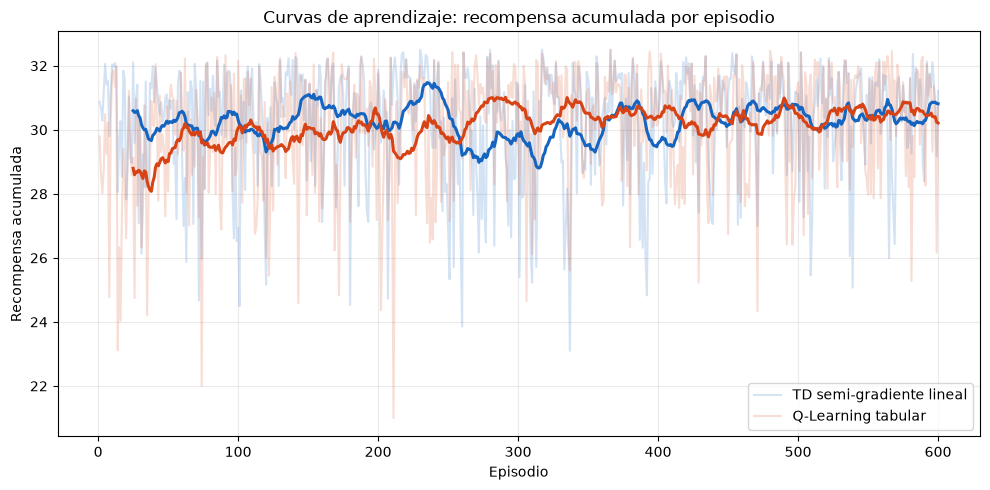

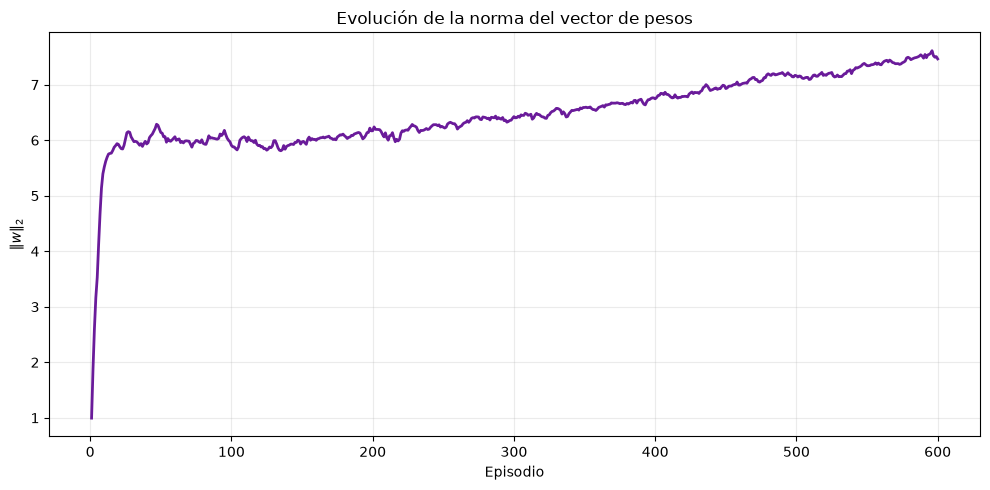

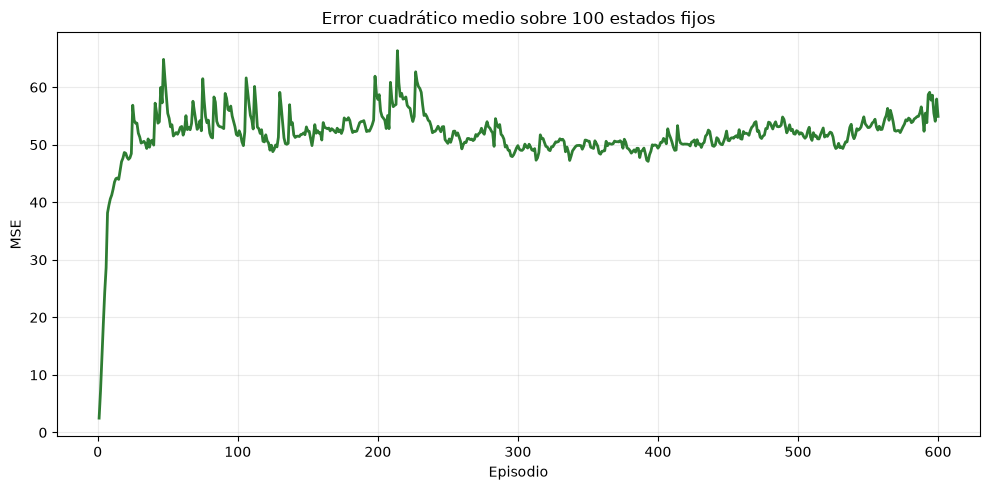

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(1, N_EPISODES + 1)
ax.plot(episodes, linear_returns, alpha=0.18, color="#1565C0", label="TD semi-gradiente lineal")
ax.plot(episodes, tabular_returns, alpha=0.18, color="#D84315", label="Q-Learning tabular")
ax.plot(np.arange(window, N_EPISODES + 1), linear_curve, color="#1565C0", linewidth=2.2)
ax.plot(np.arange(window, N_EPISODES + 1), tabular_curve, color="#D84315", linewidth=2.2)
ax.set_title("Curvas de aprendizaje: recompensa acumulada por episodio")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa acumulada")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(episodes, results["weight_norms"], color="#6A1B9A", linewidth=2)
ax.set_title("Evolución de la norma del vector de pesos")
ax.set_xlabel("Episodio")
ax.set_ylabel(r"$\|w\|_2$")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(episodes, results["mse_values"], color="#2E7D32", linewidth=2)
ax.set_title("Error cuadrático medio sobre 100 estados fijos")
ax.set_xlabel("Episodio")
ax.set_ylabel("MSE")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [7]:
# Pruebas de contrato ejecutables después de la implementación.
test_env = SimplifiedIntersectionEnv(max_steps=3)
test_obs, test_info = test_env.reset(seed=SEED)
assert isinstance(test_env, gym.Env)
assert test_env.observation_space.shape == (3,)
assert test_env.action_space.n == 2
assert test_env.observation_space.contains(test_obs)

test_next_obs, test_reward, test_terminated, test_truncated, test_step_info = test_env.step(0)
assert test_env.observation_space.contains(test_next_obs)
assert np.isfinite(test_reward)
assert isinstance(test_step_info["phase"], int)
assert results["rewards_linear"].shape == (N_EPISODES,)
assert results["rewards_tabular"].shape == (N_EPISODES,)
assert results["weight_norms"].shape == (N_EPISODES,)
assert results["mse_values"].shape == (N_EPISODES,)
assert results["fixed_states"].shape == (100, 3)
assert np.all(np.isfinite(results["weight_norms"]))
assert np.all(np.isfinite(results["mse_values"]))
assert np.all(results["mse_values"] >= 0.0)

test_env.close()
print("Pruebas de contrato: OK")
print("Actualización TD verificada: w[a] += alpha * delta * x(s), con x(s) de dimensión 15.")

Pruebas de contrato: OK
Actualización TD verificada: w[a] += alpha * delta * x(s), con x(s) de dimensión 15.
